# 1. Prepare and Clean the Dataset

In [2]:
import numpy as np
import pandas as pd
df = pd.read_excel("Trip_Analysis.xlsx")
df.head()


,Trip_Distance,Fare_Amount,Ride_Category,Surge_Multiplier,Customer_Rating,Ride_Time
0,8,270.569350,Shared,2.5,3,Non-Peak
1,21,275.161032,Economy,2.5,3,Non-Peak
2,16,359.748971,Economy,2.0,5,Non-Peak
3,12,264.044264,Premium,1.5,5,Non-Peak
4,9,225.256916,Shared,2.0,2,Non-Peak


In [3]:
df.shape

(200, 6)

In [4]:
df.describe()

,Trip_Distance,Fare_Amount,Surge_Multiplier,Customer_Rating
count,200.000000,200.000000,200.000000,200.000000
mean,15.640000,260.312376,1.677500,2.930000
std,8.433625,78.706127,0.548862,1.444136
min,2.000000,37.585916,1.000000,1.000000
25%,8.000000,208.528826,1.000000,2.000000
50%,15.000000,256.907103,1.500000,3.000000
75%,23.000000,319.763782,2.000000,4.000000
max,29.000000,468.753773,2.500000,5.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Trip_Distance     200 non-null    int64  
 1   Fare_Amount       200 non-null    float64
 2   Ride_Category     200 non-null    object 
 3   Surge_Multiplier  200 non-null    float64
 4   Customer_Rating   200 non-null    int64  
 5   Ride_Time         200 non-null    object 
dtypes: float64(2), int64(2), object(2)
memory usage: 9.5+ KB


In [6]:
df.isnull().sum()

Trip_Distance       0
Fare_Amount         0
Ride_Category       0
Surge_Multiplier    0
Customer_Rating     0
Ride_Time           0
dtype: int64

In [7]:
df.duplicated().sum()


np.int64(0)

In [8]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)

# 2. Linear Algebra concepts

In [9]:
vector = df[['Trip_Distance', 'Fare_Amount', 'Surge_Multiplier']].iloc[0].values
print("Vector:\n", vector)

Vector:
 [  8.        270.5693496   2.5      ]


In [10]:
matrix = df[['Trip_Distance', 'Fare_Amount', 'Surge_Multiplier']].head(3).values
print("Matrix:\n", matrix)

Matrix:
 [[  8.         270.5693496    2.5       ]
 [ 21.         275.16103167   2.5       ]
 [ 16.         359.74897068   2.        ]]


In [11]:
det = np.linalg.det(matrix)
print("Determinant:", det)

Determinant: 4546.838087963126


In [12]:
cov_matrix = np.cov(df[['Trip_Distance', 'Fare_Amount', 'Surge_Multiplier']].values, rowvar=False)
print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[7.11260302e+01 1.11601725e+01 7.92964824e-02]
 [1.11601725e+01 6.19465447e+03 7.52497404e-01]
 [7.92964824e-02 7.52497404e-01 3.01250000e-01]]


In [13]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print("Eigenvalues:")
print(eigenvalues)
print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[3.01072790e-01 7.11057765e+01 6.19467490e+03]

Eigenvectors:
[[-1.10078170e-03 -9.99997733e-01 -1.82249930e-03]
 [-1.19497869e-04  1.82263193e-03 -9.99998332e-01]
 [ 9.99999387e-01 -1.10056208e-03 -1.21503918e-04]]


# 3. Probability concepts

Basic Probability

In [14]:
peak = (df["Ride_Time"] == "Peak").sum()
non_peak = (df["Ride_Time"] == "Non-Peak").sum()

print("Probability of Peak Time:", peak / len(df))
print("Probability of Non-Peak Time:", non_peak / len(df))

Probability of Peak Time: 0.515
Probability of Non-Peak Time: 0.485


Conditional Probability

In [15]:
premium_peak = ((df["Ride_Category"] == "Premium") & 
                (df["Ride_Time"] == "Peak")).sum()
total_peak = (df["Ride_Time"] == "Peak").sum()
prob_premium_given_peak = premium_peak / total_peak
print("Probability of Premium given Peak Time:", prob_premium_given_peak)

Probability of Premium given Peak Time: 0.3106796116504854


Baye's Theorem

In [16]:
p_peak_given_economy = (
    ((df["Ride_Category"] == "Economy") & 
     (df["Ride_Time"] == "Peak")).sum()
    / (df["Ride_Category"] == "Economy").sum()
)
p_economy = (df["Ride_Category"] == "Economy").sum() / len(df)
p_peak = (df["Ride_Time"] == "Peak").sum() / len(df)

In [17]:
p_economy_given_peak = (
    p_peak_given_economy * p_economy
) / p_peak

print("Probability of Economy given Peak Time:", p_economy_given_peak)

Probability of Economy given Peak Time: 0.42718446601941745


Distributions

In [18]:
print(df["Ride_Category"].value_counts(normalize=True))

Ride_Category
Economy    0.41
Shared     0.30
Premium    0.29
Name: proportion, dtype: float64


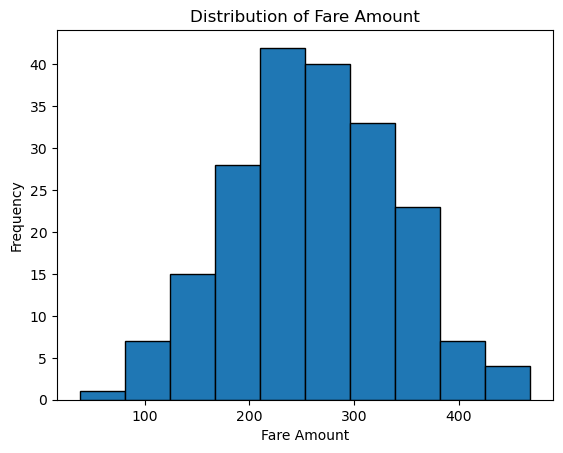

In [19]:
import matplotlib.pyplot as plt
plt.hist(df["Fare_Amount"], edgecolor='black', bins=10)
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Fare Amount")
plt.show()

# 4. Descriptive Statistics

Mean

In [20]:
print("Mean:")
print(df[['Trip_Distance', 'Fare_Amount', 'Surge_Multiplier', 'Customer_Rating']].mean())

Mean:
Trip_Distance        15.640000
Fare_Amount         260.312376
Surge_Multiplier      1.677500
Customer_Rating       2.930000
dtype: float64


Median

In [21]:
print("Mean:")
print(df[['Trip_Distance', 'Fare_Amount', 'Surge_Multiplier', 'Customer_Rating']].median())

Mean:
Trip_Distance        15.000000
Fare_Amount         256.907103
Surge_Multiplier      1.500000
Customer_Rating       3.000000
dtype: float64


Mode

In [22]:
print("Mode:")
print(df[['Trip_Distance', 'Fare_Amount', 'Surge_Multiplier', 'Customer_Rating']].mode().iloc[0])

Mode:
Trip_Distance       29.000000
Fare_Amount         37.585916
Surge_Multiplier     1.000000
Customer_Rating      1.000000
Name: 0, dtype: float64


Variance

In [23]:
print("Variance:")
print(df[['Trip_Distance', 'Fare_Amount', 'Surge_Multiplier', 'Customer_Rating']].var())

Variance:
Trip_Distance         71.126030
Fare_Amount         6194.654468
Surge_Multiplier       0.301250
Customer_Rating        2.085528
dtype: float64


Standard Deviation

In [24]:
print("Standard Deviation:")
print(df[['Trip_Distance', 'Fare_Amount', 'Surge_Multiplier', 'Customer_Rating']].std())

Standard Deviation:
Trip_Distance        8.433625
Fare_Amount         78.706127
Surge_Multiplier     0.548862
Customer_Rating      1.444136
dtype: float64


Skewness

In [25]:
print("Skewness:")
print(df[['Trip_Distance', 'Fare_Amount', 'Surge_Multiplier', 'Customer_Rating']].skew())

Skewness:
Trip_Distance       0.052817
Fare_Amount         0.022837
Surge_Multiplier    0.156067
Customer_Rating     0.062733
dtype: float64


Kurtosis

In [26]:
print("Kurtosis:")
print(df[['Trip_Distance', 'Fare_Amount', 'Surge_Multiplier', 'Customer_Rating']].kurt())

Kurtosis:
Trip_Distance      -1.270149
Fare_Amount        -0.251430
Surge_Multiplier   -1.295399
Customer_Rating    -1.323724
dtype: float64


# 5. Detecting Outliers

Percentile Method

In [27]:
lower = df["Fare_Amount"].quantile(0.90)
upper = df["Fare_Amount"].quantile(0.95)
above_90 = df[df["Fare_Amount"] > lower]
print("90th Percentile:", lower)
print("95th Percentile:", upper)
print("Outliers:")
print(above_90)

90th Percentile: 359.83011044895943
95th Percentile: 383.0853513409336
Outliers:
     Trip_Distance  Fare_Amount Ride_Category  Surge_Multiplier  \
19              22   362.316699       Premium               1.5   
39              17   360.721258        Shared               2.5   
40              16   362.416424       Economy               2.0   
41              16   361.386060        Shared               1.0   
46              26   386.528396       Premium               1.0   
63              22   453.133017        Shared               1.0   
94              16   468.753773        Shared               2.0   
113             14   391.034998        Shared               1.0   
121             25   360.560368       Economy               1.0   
128             18   364.988506       Economy               2.5   
146             17   374.830411       Premium               2.0   
150              6   441.122877        Shared               1.5   
151              4   397.473101       Economy   

Quartiles Method

In [28]:
Q1 = df["Fare_Amount"].quantile(0.25)
Q2 = df["Fare_Amount"].quantile(0.50)
Q3 = df["Fare_Amount"].quantile(0.75)

print("Q1:", Q1)
print("Q2:", Q2)
print("Q3:", Q3)

Q1: 208.5288261048614
Q2: 256.90710336367647
Q3: 319.7637824819526


IQR Method

In [29]:
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("IQR:", IQR)
print("Lower Limit:", lower)
print("Upper Limit:", upper)
outliers_iqr = df[(df["Fare_Amount"] < lower) | (df["Fare_Amount"] > upper)]

print(outliers_iqr["Fare_Amount"])

IQR: 111.23495637709121
Lower Limit: 41.67639153922457
Upper Limit: 486.61621704758943
10    37.585916
Name: Fare_Amount, dtype: float64


Z-Score Method

In [30]:
from scipy.stats import zscore
z = zscore(df["Fare_Amount"])
outliers_zscore = df[np.abs(z) > 2]
print("Z-score outliers:")
print(outliers_zscore["Fare_Amount"])

Z-score outliers:
10      37.585916
17      88.214805
63     453.133017
94     468.753773
150    441.122877
180     90.403074
187    437.839754
194     98.209841
197    418.905411
Name: Fare_Amount, dtype: float64


# 6. Measuring Relationships

Pearson Correlation

In [31]:
corr1 = df["Trip_Distance"].corr(df["Fare_Amount"])
print(corr1)
corr2 = df["Surge_Multiplier"].corr(df["Fare_Amount"])
print(corr2)
corr3 = df["Customer_Rating"].corr(df["Fare_Amount"])
print(corr3)

0.016813110993310898
0.017419389681688564
0.05272279477936421


Spearman Correlation

In [32]:
corr1 = df["Trip_Distance"].corr(df["Fare_Amount"], method="spearman")
print(corr1)
corr2 = df["Surge_Multiplier"].corr(df["Fare_Amount"], method="spearman")
print(corr2)
corr3 = df["Customer_Rating"].corr(df["Fare_Amount"], method="spearman")
print(corr3)

0.02342713443070998
0.011763994102546037
0.04749863000698679


Covariance

In [33]:
cov1 = df["Trip_Distance"].cov(df["Fare_Amount"])
print(cov1)
cov2 = df["Surge_Multiplier"].cov(df["Fare_Amount"])
print(cov2)
cov3 = df["Customer_Rating"].cov(df["Fare_Amount"])
print(cov3)

11.160172520076761
0.7524974037993288
5.992595198065078


# 7. Inferential Statistics

Bootstrapping

In [34]:
import numpy as np
fare = np.array(df["Fare_Amount"])
bootstrap_means = []
for i in range(1000):
    sample = np.random.choice(fare, size=len(fare), replace=True)
    bootstrap_means.append(np.mean(sample))
print(np.mean(bootstrap_means))

260.2080095171391


Cental Limit Theorem

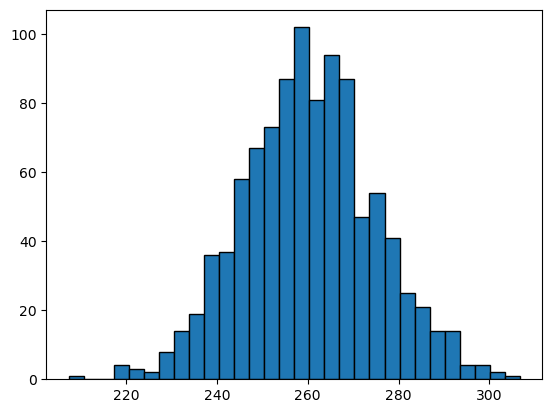

In [35]:
import numpy as np
import matplotlib.pyplot as plt
fare = np.array(df["Fare_Amount"])
sample_means = []
for i in range(1000):
    sample = np.random.choice(fare, size=30)
    sample_means.append(np.mean(sample))
plt.hist(sample_means, bins=30, edgecolor='black')
plt.show()

Point Estimation

In [36]:
sample_mean = df["Fare_Amount"].mean()
print("Point Estimate:", sample_mean)

Point Estimate: 260.31237600443757


Interval Estimation

In [37]:
import scipy.stats as stats
fare = np.array(df["Fare_Amount"])
mean = np.mean(fare)
sem = stats.sem(fare)
interval = stats.t.interval(confidence=0.95,df=len(fare)-1,loc=mean,scale=sem)
print(interval)

(np.float64(249.33772077198984), np.float64(271.2870312368853))


# 8. Hypothesis Testing

Z-test

In [38]:
import numpy as np
from statsmodels.stats.weightstats import ztest
fare = df["Fare_Amount"]
z_test, p = ztest(fare, value=250)
print(z_test, p)
if p < 0.05:
    print("\nReject the null hypothesis")
else:
    print("\nFail to reject the null hypothesis")

1.8529563724778202 0.06388861210111975

Fail to reject the null hypothesis


T-test

In [39]:
import numpy as np
from scipy.stats import ttest_1samp
fare = df["Fare_Amount"]
t_test, p = ttest_1samp(fare, 250)
print(t_test, p)
if p < 0.05:
    print("\nReject the null hypothesis")
else:
    print("\nFail to reject the null hypothesis")

1.8529563724778202 0.06536923035541557

Fail to reject the null hypothesis


Chi-square test

In [40]:
from scipy.stats import chi2_contingency
data = pd.crosstab(df["Ride_Time"], df["Ride_Category"])
chi2, p_value, dof, expected = chi2_contingency(data)
print(chi2, p_value, dof)
if p_value < 0.05:
    print("\nReject the null hypothesis")
else:
    print("\nFail to reject the null hypothesis")

1.4810469877052506 0.4768642146833866 2

Fail to reject the null hypothesis


F-test

In [41]:
from scipy.stats import f
x = df[df["Ride_Time"] == "Peak"]["Fare_Amount"]
y = df[df["Ride_Time"] == "Non-Peak"]["Fare_Amount"]
f_stat = np.var(x, ddof=1) / np.var(y, ddof=1)
df1 = len(x) - 1
df2 = len(y) - 1
p = 1 - f.cdf(f_stat, df1, df2)
print(f_stat)
print(p)
if p <= 0.05:
    print("Reject Null")
else:
    print("Fail to reject Null Hypothesis")

0.7980003886968828
0.8689314447131706
Fail to reject Null Hypothesis


ANOVA test

In [42]:
from scipy.stats import f_oneway
economy = df[df["Ride_Category"] == "Economy"]["Fare_Amount"]
premium = df[df["Ride_Category"] == "Premium"]["Fare_Amount"]
shared = df[df["Ride_Category"] == "Shared"]["Fare_Amount"]
f_stat, p = f_oneway(economy, premium, shared)
print(f_stat)
print(p)
if p < 0.05:
    print("Reject Null")
else:
    print("Fail to reject Null")

0.9284988792342405
0.3968686165946833
Fail to reject Null


A/B test

In [43]:
from scipy.stats import ttest_ind
group_A = df[df["Ride_Time"] == "Peak"]["Fare_Amount"]
group_B = df[df["Ride_Time"] == "Non-Peak"]["Fare_Amount"]
t_stat, p = ttest_ind(group_A, group_B)
print(t_stat)
print(p)
if p_value < 0.05:
    print("Significant difference between Group A and Group B")
else:
    print("No significant difference between Group A and Group B")

-0.598515832956693
0.5501798656873054
No significant difference between Group A and Group B


# Analysis Questions

1. Does trip distance significantly affect fare amount?

In [62]:
from scipy.stats import pearsonr
corr, p = pearsonr(df["Trip_Distance"], df["Fare_Amount"])
print("Pearson Correlation:", corr)
print("P value:", p)
if p < 0.05:
    print("Trip distance significantly affects fare amount")
else:
    print("Trip distance does not significantly affect fare amount")

Pearson Correlation: 0.016813110993310933
P value: 0.8132001771984588
Trip distance does not significantly affect fare amount


2. Are premium rides statistically more expensive than economy rides?

In [51]:
from scipy.stats import ttest_ind
premium = df[df["Ride_Category"] == "Premium"]["Fare_Amount"]
economy = df[df["Ride_Category"] == "Economy"]["Fare_Amount"]
t_test, p = ttest_ind(premium, economy)
print("T value", t_test)
print("P value:", p)

T value -0.4074012822247926
P value: 0.6843445588292059


In [52]:
print("Premium Mean:", premium.mean())
print("Premium Median:", premium.median())
print("Premium Std:", premium.std())

print("\nEconomy Mean:", economy.mean())
print("Economy Median:", economy.median())
print("Economy Std:", economy.std())

Premium Mean: 252.45503727502648
Premium Median: 250.89798604001987
Premium Std: 76.61133642833087

Economy Mean: 257.74844283796944
Economy Median: 259.13770041494786
Economy Std: 75.10411787252293


In [53]:
if p < 0.05 and premium.mean() > economy.mean():
    print("premium rides are statistically more expensive than economy rides.")
else:
    print("No, premium rides are not statistically more expensive than economy rides.")

No, premium rides are not statistically more expensive than economy rides.


3. Is there a relationship between surge pricing and customer ratings?

In [63]:
from scipy.stats import spearmanr

corr, p = spearmanr(df["Surge_Multiplier"], df["Customer_Rating"])

print("Spearman Correlation:", corr)
print("P value:", p)

if p < 0.05:
    print("statistically significant relationship between surge pricing and customer ratings.")
else:
    print("no statistically significant relationship between surge pricing and customer ratings.")

Spearman Correlation: -0.04709083768799108
P value: 0.5078698477562074
no statistically significant relationship between surge pricing and customer ratings.


4. Do peak-hour rides differ in revenue compared to non-peak rides?

In [65]:
from scipy.stats import ttest_ind
peak = df[df["Ride_Time"] == "Peak"]["Fare_Amount"]
non_peak = df[df["Ride_Time"] == "Non-Peak"]["Fare_Amount"]
t_test, p = ttest_ind(peak, non_peak)
print("T value:", t_test)
print("P value:", p)
if p < 0.05:
    print("peak-hour rides differ significantly in revenue compared to non-peak rides.")
else:
    print("peak-hour rides do not differ significantly in revenue compared to non-peak rides.")

T value: -0.598515832956693
P value: 0.5501798656873054
peak-hour rides do not differ significantly in revenue compared to non-peak rides.


5. Are there unusual fare values that indicate anomalies or pricing errors? 

In [68]:
Q1 = df["Fare_Amount"].quantile(0.25)
Q3 = df["Fare_Amount"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["Fare_Amount"] < lower) |(df["Fare_Amount"] > upper)]
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

print("\nUnusual Fare Values:")
print(outliers["Fare_Amount"])

print("\nNumber of Outliers:", len(outliers))

Q1: 208.5288261048614
Q3: 319.7637824819526
IQR: 111.23495637709121
Lower Bound: 41.67639153922457
Upper Bound: 486.61621704758943

Unusual Fare Values:
10    37.585916
Name: Fare_Amount, dtype: float64

Number of Outliers: 1


6. Can ride demand probabilities be estimated for different ride categories? 

In [ ]:
economy = (df["Ride_Category"] == "Economy").sum()
premium = (df["Ride_Category"] == "Premium").sum()
shared = (df["Ride_Category"] == "Shared").sum()
total = len(df)

In [73]:
prob_economy = economy / total
prob_premium = premium / total
prob_shared = shared / total

print("Economy probability:", prob_economy)
print("Premium probability:", prob_premium)
print("Shared probability:", prob_shared)

if prob_economy > prob_premium and prob_economy > prob_shared:
    print("Economy rides have the highest estimated demand probability.")
elif prob_premium > prob_economy and prob_premium > prob_shared:
    print("Premium rides have the highest estimated demand probability.")
else:
    print("Shared rides have the highest estimated demand probability.")

Economy probability: 0.41
Premium probability: 0.29
Shared probability: 0.3
Economy rides have the highest estimated demand probability.


7. Which operational factors are most strongly related to business performance?

In [74]:
corr1 = df["Trip_Distance"].corr(df["Fare_Amount"])
corr2 = df["Surge_Multiplier"].corr(df["Fare_Amount"])
corr3 = df["Customer_Rating"].corr(df["Fare_Amount"])

print("Trip Distance:", corr1)
print("Surge Multiplier:", corr2)
print("Customer Rating:", corr3)

if abs(corr1) > abs(corr2) and abs(corr1) > abs(corr3):
    print("Trip Distance is most strongly related to business performance.")
elif abs(corr2) > abs(corr1) and abs(corr2) > abs(corr3):
    print("Surge Multiplier is most strongly related to business performance.")
else:
    print("Customer Rating is most strongly related to business performance.")

Trip Distance: 0.016813110993310898
Surge Multiplier: 0.017419389681688564
Customer Rating: 0.05272279477936421
Customer Rating is most strongly related to business performance.


8. Can statistical evidence support pricing or service improvements?

In [76]:
import numpy as np

fare = df["Fare_Amount"].values
bootstrap_means = []

for i in range(1000):
    sample = np.random.choice(fare, size=len(fare), replace=True)
    bootstrap_means.append(np.mean(sample))

lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)

print("Bootstrap Mean:", np.mean(bootstrap_means))
print("95% Bootstrap Confidence Interval:", (lower, upper))

print("Statistical evidence can support pricing decisions based on the bootstrap confidence interval.")

Bootstrap Mean: 260.72248771626795
95% Bootstrap Confidence Interval: (np.float64(250.52221567529548), np.float64(270.3167351784209))
Statistical evidence can support pricing decisions based on the bootstrap confidence interval.
